#### Build the model to find whether the person will be defaulter for loan or not when income & balanceof the person provided

In [1]:
import pandas as pd
import numpy as np


In [2]:
data = pd.read_csv("Datasets/Default.csv")
data.head()

,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  object 
 1   student  10000 non-null  object 
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB


In [4]:
data.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462905
50%,823.636973,34552.644800
75%,1166.308387,43807.729275
max,2654.322576,73554.233500


In [5]:
data.shape

(10000, 4)

In [6]:
data['student'].value_counts()

student
No     7056
Yes    2944
Name: count, dtype: int64

In [7]:
data['default'].value_counts()

default
No     9667
Yes     333
Name: count, dtype: int64

In [8]:
data.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462905
50%,823.636973,34552.644800
75%,1166.308387,43807.729275
max,2654.322576,73554.233500


In [9]:
mean = data['balance'].mean()
std = data['balance'].std()

In [10]:
data[data['balance'] > mean + (3 * std)].count()      # upper bound

default    20
student    20
balance    20
income     20
dtype: int64

In [11]:
data[data['balance'] < mean - (3 * std)].count()      # lowwer bound

default    0
student    0
balance    0
income     0
dtype: int64

In [12]:
data.drop(data[data['balance'] > mean + (3 * std)].index, inplace=True)

In [13]:
data.shape

(9980, 4)

In [14]:
data.drop('student', axis = 1, inplace=True)

In [15]:
data.head()

,default,balance,income
0,No,729.526495,44361.62507
1,No,817.180407,12106.13470
2,No,1073.549164,31767.13895
3,No,529.250605,35704.49394
4,No,785.655883,38463.49588


### We will do scalling after input & output separation

In [16]:
X = data.drop('default', axis=1)
y = data['default']

In [17]:
data.describe()

,balance,income
count,9980.000000,9980.000000
mean,832.247137,33530.953295
std,479.101692,13331.877798
min,0.000000,771.967729
25%,481.127011,21357.458397
50%,821.496224,34562.497710
75%,1164.542737,43810.685280
max,2269.946966,73554.233500


In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
ss = StandardScaler()
X_ss = ss.fit_transform(X)

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X_ss, y, test_size=0.2, random_state = 40)

### Build Model

In [22]:
from sklearn.neighbors import KNeighborsClassifier

In [23]:
model = KNeighborsClassifier(n_neighbors = 3)

In [24]:
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [25]:
test_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

In [27]:
accuracy_score(y_test, test_pred)

0.9709418837675351

In [28]:
y_test.shape

(1996,)

In [29]:
y_test.value_counts()

default
No     1937
Yes      59
Name: count, dtype: int64

In [30]:
pred_df = pd.DataFrame(test_pred)

In [31]:
pred_df.value_counts()

0  
No     1957
Yes      39
Name: count, dtype: int64

In [32]:
from sklearn.metrics import confusion_matrix

In [33]:
result = confusion_matrix(y_test, test_pred)

In [34]:
pd.DataFrame(result, columns=['Pred +ve', 'Pred -ve'], index = ['Actual +ve', 'Actual -ve'])

,Pred +ve,Pred -ve
Actual +ve,1918,19
Actual -ve,39,20


### Decide K

In [35]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
train_pred = knn.predict(X_train)
test_pred = knn.predict(X_test)
accuracy_score(y_train, train_pred)


0.9770791583166333

In [36]:
accuracy_score(y_test, test_pred)

0.9709418837675351

In [37]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
train_pred = knn.predict(X_train)
test_pred = knn.predict(X_test)
accuracy_score(y_train, train_pred)


0.9750751503006012

In [38]:
accuracy_score(y_test, test_pred)

0.9719438877755511

In [39]:
train_acc = []
test_acc = []
k_values = []
for i in range(3, 16, 2):
    k_values.append(i)
    knn = KNeighborsClassifier(n_neighbors= i)
    knn.fit(X_train, y_train)
    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)
    train_acc.append(accuracy_score(y_train, train_pred))
    test_acc.append(accuracy_score(y_test, test_pred))


In [40]:
train_acc

[0.9770791583166333,
 0.9750751503006012,
 0.9753256513026052,
 0.9738226452905812,
 0.9736973947895792,
 0.9739478957915831,
 0.9730711422845691]

In [41]:
test_acc

[0.9709418837675351,
 0.9719438877755511,
 0.9739478957915831,
 0.9774549098196392,
 0.9774549098196392,
 0.9784569138276553,
 0.9799599198396793]

In [42]:
import matplotlib.pyplot as plt

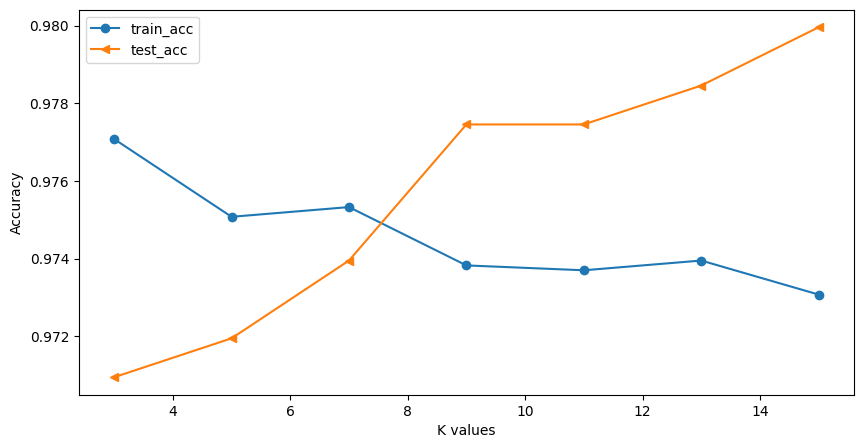

In [43]:
plt.figure(figsize = (10,5))
plt.plot(k_values, train_acc, marker='o', label='train_acc')
plt.plot(k_values, test_acc, marker='<', label = 'test_acc')
plt.xlabel('K values')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [44]:
from sklearn.metrics import precision_score, recall_score

In [45]:
precision_score(y_test, test_pred, pos_label='Yes')

0.8518518518518519

In [46]:
precision_score(y_test, test_pred, pos_label='No')

0.9817166074149314

In [47]:
recall_score(y_test, test_pred, pos_label='Yes')

0.3898305084745763

In [48]:
recall_score(y_test, test_pred, pos_label='No')

0.9979349509550852

In [50]:
from sklearn.metrics import classification_report
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

          No       0.98      1.00      0.99      1937
         Yes       0.85      0.39      0.53        59

    accuracy                           0.98      1996
   macro avg       0.92      0.69      0.76      1996
weighted avg       0.98      0.98      0.98      1996

